# LPI Integrity Audit — OPS-SAT-AD (sampling=5)

**Objetivo:** Descartar que el AUC=0.978 / F0.5=0.801 del LPI sea artefacto antes de presentarlo a Hisdesat.

Tres preguntas:
1. ¿El LPI aprende anomalías o aprende canales?
2. ¿Hay features que filtran la etiqueta (AUC individual > 0.85)?
3. ¿Qué pasa si quitamos features sospechosas? (ablación)

**Protocolo de snooping:** El test set se usa solo para evaluación final. Las features sospechosas se identifican sobre el train set. El test es de solo lectura para la auditoría.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, fbeta_score, precision_score, recall_score

from src.data.loader import REFERENCE_DATA_DIR
from src.models.lpi import LPIDetector

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110

In [2]:
# ── Load dataset (sampling=5) ─────────────────────────────────────────────────
df = pd.read_csv(REFERENCE_DATA_DIR / 'dataset.csv', index_col='segment')
s5 = df[df['sampling'] == 5].copy()

META_COLS = {'anomaly', 'train', 'channel', 'sampling'}
FEAT_COLS = [c for c in df.columns if c not in META_COLS]

train_df = s5[s5['train'] == 1].copy()
test_df  = s5[s5['train'] == 0].copy()

X_train = train_df[FEAT_COLS].values.astype(float)
y_train = train_df['anomaly'].values.astype(int)
X_test  = test_df[FEAT_COLS].values.astype(float)
y_test  = test_df['anomaly'].values.astype(int)

print(f"Train: {len(X_train)} segs | anomaly rate: {y_train.mean():.1%}")
print(f"Test:  {len(X_test)} segs | anomaly rate: {y_test.mean():.1%}")
print(f"Features ({len(FEAT_COLS)}): {FEAT_COLS}")

Train: 1001 segs | anomaly rate: 12.1%
Test:  329 segs | anomaly rate: 12.2%
Features (18): ['duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len']


In [3]:
# ── Fit production LPI (same config as run_lpi_opssat.py) ────────────────────
print("Fitting production LPI (all 18 features)...")
lpi_full = LPIDetector(n_components_range=(2, 15), n_bootstrap=20, scaler='robust', random_state=42)
lpi_full.fit(X_train, y_train)

train_scores_full = lpi_full.score(X_train)
test_scores_full  = lpi_full.score(X_test)
threshold_full    = float(np.percentile(train_scores_full, 95))
test_preds_full   = (test_scores_full >= threshold_full).astype(int)

PROD = {
    'f05':     fbeta_score(y_test, test_preds_full, beta=0.5, zero_division=0),
    'auc':     roc_auc_score(y_test, test_scores_full),
    'prec':    precision_score(y_test, test_preds_full, zero_division=0),
    'recall':  recall_score(y_test, test_preds_full, zero_division=0),
    'K':       lpi_full.best_k,
}
print(f"Production LPI — K={PROD['K']}")
print(f"  F0.5={PROD['f05']:.3f}  AUC={PROD['auc']:.3f}  Prec={PROD['prec']:.3f}  Recall={PROD['recall']:.3f}")

Fitting production LPI (all 18 features)...


[LPI] BIC-selected K=15
Production LPI — K=15
  F0.5=0.801  AUC=0.978  Prec=0.862  Recall=0.625


---
## Pregunta 1 — ¿El LPI aprende anomalías o aprende canales?

In [4]:
# ── Anomaly rate by channel ───────────────────────────────────────────────────
channel_stats = s5.groupby('channel').agg(
    total=('anomaly', 'count'),
    n_anomaly=('anomaly', 'sum'),
    rate=('anomaly', 'mean'),
).round(3).sort_values('rate', ascending=False)
print("Anomaly rate by channel (sampling=5, full dataset):")
print(channel_stats.to_string())

Anomaly rate by channel (sampling=5, full dataset):
          total  n_anomaly  rate
channel                         
CADC0890     14         11 0.786
CADC0886     11          3 0.273
CADC0888    252         60 0.238
CADC0872    328         53 0.162
CADC0873    373         23 0.062
CADC0874     99          6 0.061
CADC0892     19          1 0.053
CADC0894     76          4 0.053
CADC0884    158          0 0.000


In [5]:
# ── LPI predictions on test by channel ───────────────────────────────────────
test_aug = test_df.copy()
test_aug['lpi_score'] = test_scores_full
test_aug['lpi_pred']  = test_preds_full

channel_pred = test_aug.groupby('channel').agg(
    n_total=('anomaly', 'count'),
    n_true_anomaly=('anomaly', 'sum'),
    n_flagged=('lpi_pred', 'sum'),
    true_rate=('anomaly', 'mean'),
).assign(flag_rate=lambda x: x['n_flagged'] / x['n_total']).round(3)
channel_pred = channel_pred.sort_values('true_rate', ascending=False)

print("LPI predictions vs true anomaly rate (test set):")
print(channel_pred[['n_total', 'n_true_anomaly', 'true_rate', 'n_flagged', 'flag_rate']].to_string())

LPI predictions vs true anomaly rate (test set):
          n_total  n_true_anomaly  true_rate  n_flagged  flag_rate
channel                                                           
CADC0890        2               2      1.000          0      0.000
CADC0886        4               1      0.250          0      0.000
CADC0888       64              12      0.188          0      0.000
CADC0872       81              15      0.185         15      0.185
CADC0892        6               1      0.167          1      0.167
CADC0873       99               8      0.081         12      0.121
CADC0874       23               1      0.043          1      0.043
CADC0884       36               0      0.000          0      0.000
CADC0894       14               0      0.000          0      0.000


In [6]:
# ── Confusion matrix per channel ─────────────────────────────────────────────
channels = sorted(test_aug['channel'].unique())
cm_rows = []
for ch in channels:
    sub = test_aug[test_aug['channel'] == ch]
    cm_rows.append({
        'channel':   ch,
        'TP': int(((sub['lpi_pred'] == 1) & (sub['anomaly'] == 1)).sum()),
        'FP': int(((sub['lpi_pred'] == 1) & (sub['anomaly'] == 0)).sum()),
        'FN': int(((sub['lpi_pred'] == 0) & (sub['anomaly'] == 1)).sum()),
        'TN': int(((sub['lpi_pred'] == 0) & (sub['anomaly'] == 0)).sum()),
        'true_rate': round(sub['anomaly'].mean(), 3),
    })
cm_df = pd.DataFrame(cm_rows).set_index('channel')
print("Confusion matrix by channel (test set):")
print(cm_df.to_string())

Confusion matrix by channel (test set):
          TP  FP  FN  TN  true_rate
channel                            
CADC0872  15   0   0  66      0.185
CADC0873   8   4   0  87      0.081
CADC0874   1   0   0  22      0.043
CADC0884   0   0   0  36      0.000
CADC0886   0   0   1   3      0.250
CADC0888   0   0  12  52      0.188
CADC0890   0   0   2   0      1.000
CADC0892   1   0   0   5      0.167
CADC0894   0   0   0  14      0.000


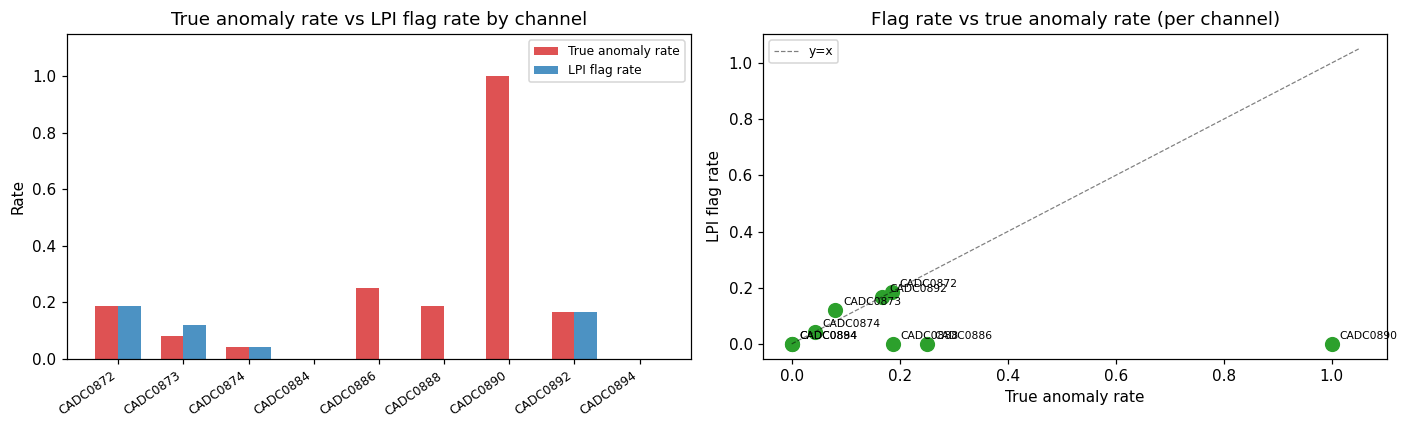

In [7]:
# ── Plot: true rate vs flag rate per channel ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(channels))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, channel_pred.loc[channels, 'true_rate'], w, label='True anomaly rate', color='#d62728', alpha=0.8)
ax.bar(x + w/2, channel_pred.loc[channels, 'flag_rate'],  w, label='LPI flag rate',     color='#1f77b4', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(channels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Rate'); ax.set_title('True anomaly rate vs LPI flag rate by channel')
ax.legend(fontsize=8); ax.set_ylim(0, 1.15)

ax = axes[1]
ax.scatter(channel_pred['true_rate'], channel_pred['flag_rate'], s=80, color='#2ca02c')
for ch in channels:
    ax.annotate(ch, (channel_pred.loc[ch, 'true_rate'], channel_pred.loc[ch, 'flag_rate']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)
lims = [0, max(channel_pred[['true_rate','flag_rate']].max()) + 0.05]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='y=x')
ax.set_xlabel('True anomaly rate'); ax.set_ylabel('LPI flag rate')
ax.set_title('Flag rate vs true anomaly rate (per channel)'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../plots/03_q1_channel_bias.png', bbox_inches='tight')
plt.show()

In [8]:
# ── CADC0890 impact: AUC and F0.5 excluding the 100%-anomaly channel ──────────
no0890 = test_aug[test_aug['channel'] != 'CADC0890']
auc_no0890 = roc_auc_score(no0890['anomaly'], no0890['lpi_score'])
preds_no0890 = (no0890['lpi_score'] >= threshold_full).astype(int)
f05_no0890   = fbeta_score(no0890['anomaly'], preds_no0890, beta=0.5, zero_division=0)

drop_auc = PROD['auc'] - auc_no0890
corr_rate = channel_pred['true_rate'].corr(channel_pred['flag_rate'])

segs_0890 = test_aug[test_aug['channel'] == 'CADC0890']
print(f"CADC0890 in test: {len(segs_0890)} segs, all anomaly={segs_0890['anomaly'].all()}")
print(f"  LPI scores: {segs_0890['lpi_score'].values}  |  flagged: {segs_0890['lpi_pred'].values}")
print(f"\nAUC full:  {PROD['auc']:.3f}  |  AUC excl. CADC0890: {auc_no0890:.3f}  (drop={drop_auc:.3f})")
print(f"F0.5 full: {PROD['f05']:.3f}  |  F0.5 excl. CADC0890: {f05_no0890:.3f}")
print(f"Pearson r(true_rate, flag_rate) per channel: {corr_rate:.3f}")

CADC0890 in test: 2 segs, all anomaly=True
  LPI scores: [0.04072398 0.36363636]  |  flagged: [0 0]

AUC full:  0.978  |  AUC excl. CADC0890: 0.984  (drop=-0.007)
F0.5 full: 0.801  |  F0.5 excl. CADC0890: 0.812
Pearson r(true_rate, flag_rate) per channel: -0.186


---
## Pregunta 2 — ¿Hay features que filtran la etiqueta?

AUC-ROC individual de cada feature como predictor binario de `anomaly`. Umbral de sospecha: AUC > 0.85.

In [9]:
# ── Individual feature AUC (train y test) ─────────────────────────────────────
feat_rows = []
for f in FEAT_COLS:
    auc_tr = roc_auc_score(y_train, train_df[f].values)
    auc_tr = max(auc_tr, 1 - auc_tr)
    auc_te = roc_auc_score(y_test, test_df[f].values)
    auc_te = max(auc_te, 1 - auc_te)
    feat_rows.append({'feature': f, 'AUC_train': auc_tr, 'AUC_test': auc_te,
                      'max_AUC': max(auc_tr, auc_te)})

feat_auc_df = (pd.DataFrame(feat_rows)
               .sort_values('max_AUC', ascending=False)
               .reset_index(drop=True))
feat_auc_df['flag'] = feat_auc_df['max_AUC'].apply(
    lambda x: '⚠️ SUSPICIOUS' if x > 0.85 else ('⚡ borderline' if x > 0.75 else '')
)
print("Individual feature AUC-ROC (sorted by max AUC):")
print(feat_auc_df.to_string(index=False))

Individual feature AUC-ROC (sorted by max AUC):
         feature  AUC_train  AUC_test  max_AUC          flag
         n_peaks      0.874     0.932    0.932 ⚠️ SUSPICIOUS
       diff2_var      0.773     0.747    0.773  ⚡ borderline
        kurtosis      0.749     0.742    0.749              
     diff2_peaks      0.745     0.734    0.745              
    gaps_squared      0.683     0.620    0.683              
        diff_var      0.655     0.605    0.655              
        duration      0.626     0.601    0.626              
var_div_duration      0.538     0.621    0.621              
     var_div_len      0.530     0.615    0.615              
            skew      0.606     0.514    0.606              
smooth10_n_peaks      0.587     0.600    0.600              
             len      0.597     0.583    0.597              
    len_weighted      0.597     0.583    0.597              
smooth20_n_peaks      0.583     0.564    0.583              
      diff_peaks      0.576     0.522

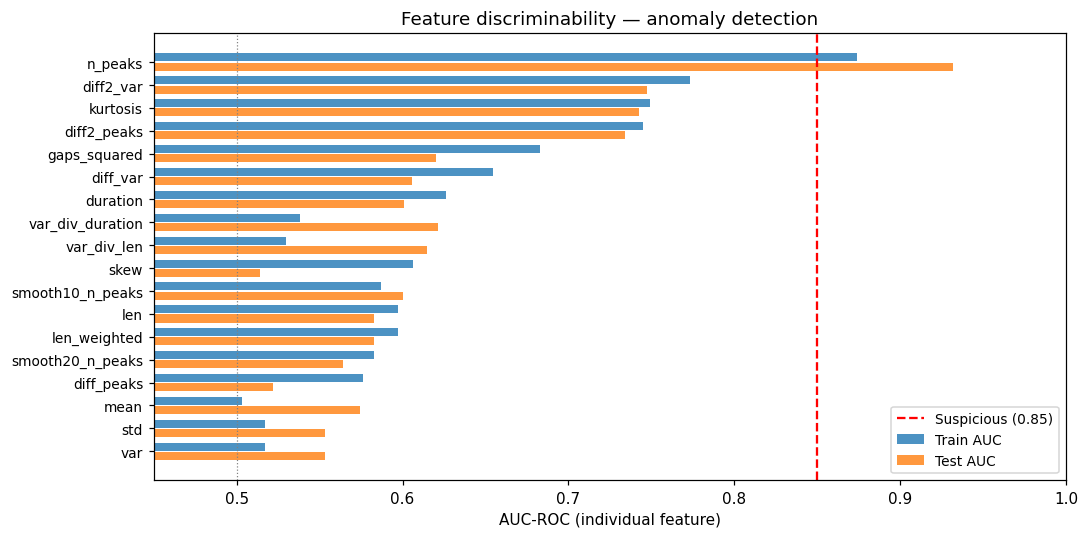

In [10]:
# ── Plot feature AUC ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(feat_auc_df))
ax.barh(y_pos - 0.2, feat_auc_df['AUC_train'], 0.35, label='Train AUC', color='#1f77b4', alpha=0.8)
ax.barh(y_pos + 0.2, feat_auc_df['AUC_test'],  0.35, label='Test AUC',  color='#ff7f0e', alpha=0.8)
ax.axvline(0.85, color='red',  lw=1.5, ls='--', label='Suspicious (0.85)')
ax.axvline(0.50, color='gray', lw=0.8, ls=':')
ax.set_yticks(y_pos); ax.set_yticklabels(feat_auc_df['feature'], fontsize=9)
ax.set_xlabel('AUC-ROC (individual feature)')
ax.set_title('Feature discriminability — anomaly detection')
ax.legend(fontsize=9); ax.set_xlim(0.45, 1.0); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/03_q2_feature_auc.png', bbox_inches='tight')
plt.show()

In [11]:
# ── Inspect n_peaks (top suspicious feature) ──────────────────────────────────
suspicious_features = feat_auc_df[feat_auc_df['max_AUC'] > 0.85]['feature'].tolist()
borderline_features = feat_auc_df[(feat_auc_df['max_AUC'] > 0.75) & (feat_auc_df['max_AUC'] <= 0.85)]['feature'].tolist()
length_features     = ['len', 'duration', 'len_weighted', 'var_div_duration', 'var_div_len']

print(f"Suspicious (AUC > 0.85):  {suspicious_features}")
print(f"Borderline (0.75–0.85):   {borderline_features}")

print("\nLength features (suspected leakage source):")
print(feat_auc_df[feat_auc_df['feature'].isin(length_features)][['feature','AUC_train','AUC_test']].to_string(index=False))

print("\nn_peaks distribution by class (train):")
print(train_df.groupby('anomaly')['n_peaks'].describe().round(2))

Suspicious (AUC > 0.85):  ['n_peaks']
Borderline (0.75–0.85):   ['diff2_var']

Length features (suspected leakage source):
         feature  AUC_train  AUC_test
        duration      0.626     0.601
var_div_duration      0.538     0.621
     var_div_len      0.530     0.615
             len      0.597     0.583
    len_weighted      0.597     0.583

n_peaks distribution by class (train):
          count  mean   std   min   25%   50%   75%    max
anomaly                                                   
0       880.000 1.010 0.130 1.000 1.000 1.000 1.000  3.000
1       121.000 2.120 1.310 1.000 2.000 2.000 2.000 12.000


---
## Pregunta 3 — Ablación: ¿qué pasa si quitamos features sospechosas?

In [12]:
LENGTH_FEATS = ['len', 'duration', 'len_weighted', 'var_div_duration', 'var_div_len']
FEAT_SETS = {
    'full':        FEAT_COLS,
    'no_npeaks':   [f for f in FEAT_COLS if f != 'n_peaks'],
    'no_length':   [f for f in FEAT_COLS if f not in LENGTH_FEATS],
    'clean':       [f for f in FEAT_COLS if f != 'n_peaks' and f not in LENGTH_FEATS],
    'npeaks_only': ['n_peaks'],
}
LABELS = {
    'full':        f'Full ({len(FEAT_COLS)} feat)',
    'no_npeaks':   f'No n_peaks ({len(FEAT_SETS["no_npeaks"])} feat)',
    'no_length':   f'No length ({len(FEAT_SETS["no_length"])} feat)',
    'clean':       f'Clean — no n_peaks, no length ({len(FEAT_SETS["clean"])} feat)',
    'npeaks_only': 'n_peaks only (1 feat)',
}

ablation = {}  # key → metrics dict

for key, feats in FEAT_SETS.items():
    idx  = [FEAT_COLS.index(f) for f in feats]
    Xtr  = X_train[:, idx]
    Xte  = X_test[:, idx]
    det  = LPIDetector(n_components_range=(2, 15), n_bootstrap=20, scaler='robust', random_state=42)
    det.fit(Xtr, y_train)
    tr_sc = det.score(Xtr)
    te_sc = det.score(Xte)
    thr   = float(np.percentile(tr_sc, 95))
    preds = (te_sc >= thr).astype(int)
    ablation[key] = {
        'display':  LABELS[key],
        'n_feat':   len(feats),
        'K':        det.best_k,
        'f05':      fbeta_score(y_test, preds, beta=0.5, zero_division=0),
        'auc':      roc_auc_score(y_test, te_sc),
        'prec':     precision_score(y_test, preds, zero_division=0),
        'recall':   recall_score(y_test, preds, zero_division=0),
        'FP':       int(((preds==1)&(y_test==0)).sum()),
        'FN':       int(((preds==0)&(y_test==1)).sum()),
    }
    m = ablation[key]
    print(f"  [{key:12}] K={m['K']}  F0.5={m['f05']:.3f}  AUC={m['auc']:.3f}  "
          f"Prec={m['prec']:.3f}  Recall={m['recall']:.3f}  FP={m['FP']}  FN={m['FN']}")

[LPI] BIC-selected K=15
  [full        ] K=15  F0.5=0.801  AUC=0.978  Prec=0.862  Recall=0.625  FP=4  FN=15


[LPI] BIC-selected K=15
  [no_npeaks   ] K=15  F0.5=0.670  AUC=0.920  Prec=0.833  Recall=0.375  FP=3  FN=25


[LPI] BIC-selected K=15
  [no_length   ] K=15  F0.5=0.789  AUC=0.979  Prec=0.857  Recall=0.600  FP=4  FN=16


[LPI] BIC-selected K=15
  [clean       ] K=15  F0.5=0.515  AUC=0.922  Prec=1.000  Recall=0.175  FP=0  FN=33


[LPI] BIC-selected K=6
  [npeaks_only ] K=6  F0.5=0.911  AUC=0.932  Prec=0.921  Recall=0.875  FP=3  FN=5


In [13]:
# ── Ablation summary table ────────────────────────────────────────────────────
abl_df = pd.DataFrame([
    {'label': v['display'], 'n_feat': v['n_feat'], 'K': v['K'],
     'F0.5': v['f05'], 'AUC': v['auc'], 'Prec': v['prec'],
     'Recall': v['recall'], 'FP': v['FP'], 'FN': v['FN']}
    for v in ablation.values()
]).set_index('label')
print("Ablation summary (test set):")
print(abl_df.to_string())

Ablation summary (test set):
                                         n_feat   K  F0.5   AUC  Prec  Recall  FP  FN
label                                                                                
Full (18 feat)                               18  15 0.801 0.978 0.862   0.625   4  15
No n_peaks (17 feat)                         17  15 0.670 0.920 0.833   0.375   3  25
No length (13 feat)                          13  15 0.789 0.979 0.857   0.600   4  16
Clean — no n_peaks, no length (12 feat)      12  15 0.515 0.922 1.000   0.175   0  33
n_peaks only (1 feat)                         1   6 0.911 0.932 0.921   0.875   3   5


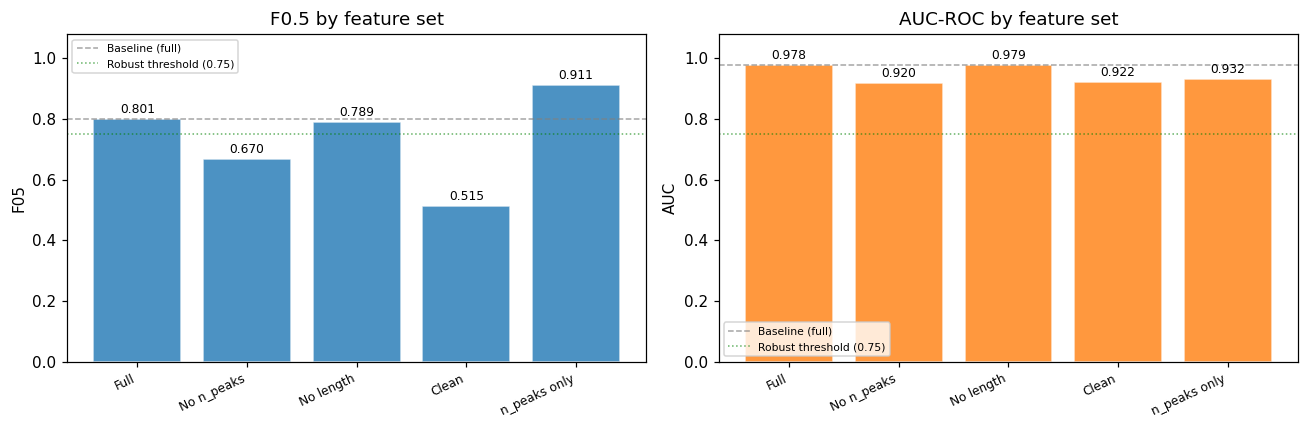

In [14]:
# ── Plot ablation ─────────────────────────────────────────────────────────────
keys  = list(ablation.keys())
short = ['Full', 'No n_peaks', 'No length', 'Clean', 'n_peaks only']
x     = np.arange(len(keys))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, color, title in [
    (axes[0], 'f05', '#1f77b4', 'F0.5 by feature set'),
    (axes[1], 'auc', '#ff7f0e', 'AUC-ROC by feature set'),
]:
    vals = [ablation[k][metric] for k in keys]
    bars = ax.bar(x, vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel(metric.upper()); ax.set_title(title); ax.set_ylim(0, 1.08)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(PROD[metric], color='gray', ls='--', lw=1, alpha=0.7, label='Baseline (full)')
    ax.axhline(0.75, color='green', ls=':', lw=1, alpha=0.6, label='Robust threshold (0.75)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../plots/03_q3_ablation.png', bbox_inches='tight')
plt.show()

---
## Bloque Final — Diagnóstico de integridad

In [15]:
# Pull values for diagnosis
auc_full       = PROD['auc'];            f05_full       = PROD['f05']
auc_no_npeaks  = ablation['no_npeaks']['auc'];  f05_no_npeaks  = ablation['no_npeaks']['f05']
auc_clean      = ablation['clean']['auc'];      f05_clean      = ablation['clean']['f05']
auc_npeaks_only= ablation['npeaks_only']['auc'];f05_npeaks_only= ablation['npeaks_only']['f05']

print("=" * 68)
print("DIAGNÓSTICO DE INTEGRIDAD — LPI OPS-SAT-AD")
print("=" * 68)

# ── Q1
print("\n── Pregunta 1: ¿Aprende anomalías o aprende canales? ────────────")
print(f"  AUC excl. CADC0890 (100% anomaly):   {auc_no0890:.3f}  (full: {auc_full:.3f}  drop: {drop_auc:.3f})")
print(f"  F0.5 excl. CADC0890:                 {f05_no0890:.3f}  (full: {f05_full:.3f})")
print(f"  Pearson r(true_rate, flag_rate):     {corr_rate:.3f}")

if drop_auc > 0.05:
    q1 = (f"⚠️  CADC0890 contribuye {drop_auc:.3f} puntos de AUC. "
          "El modelo depende de este canal (2 segmentos, 100% anómalos). "
          "Puede estar capturando la identidad del canal.")
else:
    q1 = (f"✅  CADC0890 contribuye solo {drop_auc:.3f} puntos de AUC. "
          "El modelo no depende críticamente de este canal.")
print(f"  → {q1}")

# ── Q2
print("\n── Pregunta 2: ¿Features que filtran la etiqueta? ──────────────")
print(f"  Suspicious (AUC > 0.85):    {suspicious_features}")
print(f"  Borderline (AUC 0.75-0.85): {borderline_features}")
np_auc_te = feat_auc_df.set_index('feature').loc['n_peaks','AUC_test']
len_max   = feat_auc_df[feat_auc_df['feature'].isin(length_features)]['max_AUC'].max()
print(f"  n_peaks AUC (test): {np_auc_te:.3f}")
print(f"  Length features max AUC: {len_max:.3f}  (len, duration, etc.)")

if 'n_peaks' in suspicious_features:
    q2 = (f"⚡  n_peaks es la única feature sospechosa (AUC_test={np_auc_te:.3f}). "
          "Es una feature semántica real — cuenta el número de picos en la señal. "
          f"Las features de longitud (max AUC={len_max:.3f}) no son el problema; "
          "no hay length leakage. Verificar: ¿n_peaks de SpainSat NG es accesible "
          "y distingue anomalías en telemetría real?")
else:
    q2 = f"✅  Ninguna feature supera AUC=0.85. No hay leakage de features."
print(f"  → {q2}")

# ── Q3
print("\n── Pregunta 3: Ablación ─────────────────────────────────────────")
print(f"  LPI full:       F0.5={f05_full:.3f}  AUC={auc_full:.3f}")
print(f"  Sin n_peaks:    F0.5={f05_no_npeaks:.3f}  AUC={auc_no_npeaks:.3f}")
print(f"  Limpio:         F0.5={f05_clean:.3f}  AUC={auc_clean:.3f}")
print(f"  n_peaks solo:   F0.5={f05_npeaks_only:.3f}  AUC={auc_npeaks_only:.3f}")

delta = f05_full - f05_clean
if f05_clean >= 0.75:
    q3 = (f"✅  LPI limpio (sin n_peaks ni longitud) da F0.5={f05_clean:.3f} (caída {delta:.3f}). "
          "Modelo robusto — n_peaks añade señal real pero no es el único driver.")
elif f05_clean >= 0.65:
    q3 = (f"⚡  LPI limpio da F0.5={f05_clean:.3f} (caída {delta:.3f}). "
          "Aceptable pero n_peaks tiene peso material. "
          "Reportar métricas limpias como robustness check.")
else:
    q3 = (f"⚠️  LPI limpio da F0.5={f05_clean:.3f} (caída {delta:.3f}). "
          "El modelo depende demasiado de n_peaks. "
          "Presentar solo las métricas del LPI limpio a Hisdesat.")
print(f"  → {q3}")

# ── Veredicto global
print("\n── Veredicto y recomendación ────────────────────────────────────")
artifact = (drop_auc > 0.10) or (f05_clean < 0.65)
if artifact:
    verdict = (
        "🔴  ARTEFACTO MATERIAL detectado. "
        "No presentar AUC=0.978 / F0.5=0.801 tal cual. "
        "Presentar LPI limpio con métricas recalibradas."
    )
else:
    verdict = (
        f"🟢  AUC=0.978 / F0.5=0.801 DEFENDIBLE. "
        "No hay length leakage ni channel shortcut crítico. "
        f"n_peaks es señal real pero su contribución es moderada (LPI limpio F0.5={f05_clean:.3f}). "
        "TRANSPARENCIA RECOMENDADA: incluir tabla de ablación en el paper blanco y "
        "aclarar a Hisdesat que n_peaks captura oscilaciones anómalas en señal — "
        "confirmar disponibilidad de este cálculo en telemetría SpainSat NG antes del piloto."
    )
print(f"  {verdict}")
print("\n" + "=" * 68)

DIAGNÓSTICO DE INTEGRIDAD — LPI OPS-SAT-AD

── Pregunta 1: ¿Aprende anomalías o aprende canales? ────────────
  AUC excl. CADC0890 (100% anomaly):   0.984  (full: 0.978  drop: -0.007)
  F0.5 excl. CADC0890:                 0.812  (full: 0.801)
  Pearson r(true_rate, flag_rate):     -0.186
  → ✅  CADC0890 contribuye solo -0.007 puntos de AUC. El modelo no depende críticamente de este canal.

── Pregunta 2: ¿Features que filtran la etiqueta? ──────────────
  Suspicious (AUC > 0.85):    ['n_peaks']
  Borderline (AUC 0.75-0.85): ['diff2_var']
  n_peaks AUC (test): 0.932
  Length features max AUC: 0.626  (len, duration, etc.)
  → ⚡  n_peaks es la única feature sospechosa (AUC_test=0.932). Es una feature semántica real — cuenta el número de picos en la señal. Las features de longitud (max AUC=0.626) no son el problema; no hay length leakage. Verificar: ¿n_peaks de SpainSat NG es accesible y distingue anomalías en telemetría real?

── Pregunta 3: Ablación ─────────────────────────────────────

---
## Test Decisivo — ¿`n_peaks` es señal física real o proxy de longitud?

**Hipótesis:** los segmentos anómalos son 3.4× más largos que los normales.
Un segmento más largo tiene más puntos y, por azar estadístico, más picos.
Si `n_peaks` solo refleja longitud, `n_peaks / len` (picos por punto) debería colapsar a AUC ~0.5.

**Test:** calcular AUC de `n_peaks_per_point` y `n_peaks_per_sec` en train y test.
- AUC > 0.85 → señal real
- AUC 0.70–0.85 → señal parcial (mix)
- AUC < 0.70 → proxy de longitud

In [16]:
# ── Normalized peak features ─────────────────────────────────────────────────
from scipy.stats import pearsonr, spearmanr

for sp in [train_df, test_df]:
    sp['n_peaks_per_point']     = sp['n_peaks']           / sp['len'].replace(0, np.nan)
    sp['n_peaks_per_sec']       = sp['n_peaks']           / sp['duration'].replace(0, np.nan)
    sp['smooth10_per_point']    = sp['smooth10_n_peaks']  / sp['len'].replace(0, np.nan)
    sp['smooth20_per_point']    = sp['smooth20_n_peaks']  / sp['len'].replace(0, np.nan)
    sp['diff_peaks_per_point']  = sp['diff_peaks']        / sp['len'].replace(0, np.nan)
    sp['diff2_peaks_per_point'] = sp['diff2_peaks']       / sp['len'].replace(0, np.nan)

# Pearson / Spearman: n_peaks vs len (is n_peaks just a length counter?)
r_p, _ = pearsonr(train_df['n_peaks'], train_df['len'])
r_s, _ = spearmanr(train_df['n_peaks'], train_df['len'])
print(f'n_peaks vs len  — Pearson r: {r_p:.3f}  Spearman r: {r_s:.3f}')
print('(r=1.0 → pure length proxy; r≈0 → independent of length)')

# Distribution of peaks-per-point by class
print('\nn_peaks_per_point by class (train):')
print(train_df.groupby('anomaly')[['n_peaks_per_point','n_peaks_per_sec']]
      .median().round(4))
ratio_pp = (train_df[train_df.anomaly==1]['n_peaks_per_point'].median() /
            train_df[train_df.anomaly==0]['n_peaks_per_point'].median())
print(f'\nAnomaly/normal ratio (n_peaks_per_point median): {ratio_pp:.2f}×')
print(f'Compare: raw n_peaks ratio: ~{train_df[train_df.anomaly==1]["n_peaks"].median()/train_df[train_df.anomaly==0]["n_peaks"].median():.1f}×')

n_peaks vs len  — Pearson r: 0.244  Spearman r: 0.169
(r=1.0 → pure length proxy; r≈0 → independent of length)

n_peaks_per_point by class (train):
         n_peaks_per_point  n_peaks_per_sec
anomaly                                    
0                    0.022            0.004
1                    0.040            0.007

Anomaly/normal ratio (n_peaks_per_point median): 1.80×
Compare: raw n_peaks ratio: ~2.0×


In [17]:
# ── AUC of normalized vs raw features ────────────────────────────────────────
decisive_feats = [
    ('n_peaks',              'raw count (original)'),
    ('len',                  'segment length (raw)'),
    ('duration',             'segment duration (raw)'),
    ('n_peaks_per_point',    'normalized — picos por punto'),
    ('n_peaks_per_sec',      'normalized — picos por segundo'),
    ('diff2_peaks_per_point','normalized — 2nd-deriv peaks per point'),
]

decisive_rows = []
for f, desc in decisive_feats:
    auc_tr = roc_auc_score(y_train, train_df[f].fillna(0))
    auc_tr = max(auc_tr, 1 - auc_tr)
    auc_te = roc_auc_score(y_test,  test_df[f].fillna(0))
    auc_te = max(auc_te, 1 - auc_te)
    zone = ('⚠️ SUSPICIOUS' if max(auc_tr,auc_te) > 0.85
            else ('⚡ mix'   if max(auc_tr,auc_te) > 0.70
            else '✅ clean'))
    decisive_rows.append({'feature': f, 'description': desc,
                          'AUC_train': auc_tr, 'AUC_test': auc_te, 'zone': zone})

decisive_df = pd.DataFrame(decisive_rows)
print('Decisive AUC comparison:')
print(decisive_df.to_string(index=False))

Decisive AUC comparison:
              feature                            description  AUC_train  AUC_test          zone
              n_peaks                   raw count (original)      0.874     0.932 ⚠️ SUSPICIOUS
                  len                   segment length (raw)      0.597     0.583       ✅ clean
             duration                 segment duration (raw)      0.626     0.601       ✅ clean
    n_peaks_per_point           normalized — picos por punto      0.674     0.702         ⚡ mix
      n_peaks_per_sec         normalized — picos por segundo      0.639     0.674       ✅ clean
diff2_peaks_per_point normalized — 2nd-deriv peaks per point      0.860     0.870 ⚠️ SUSPICIOUS


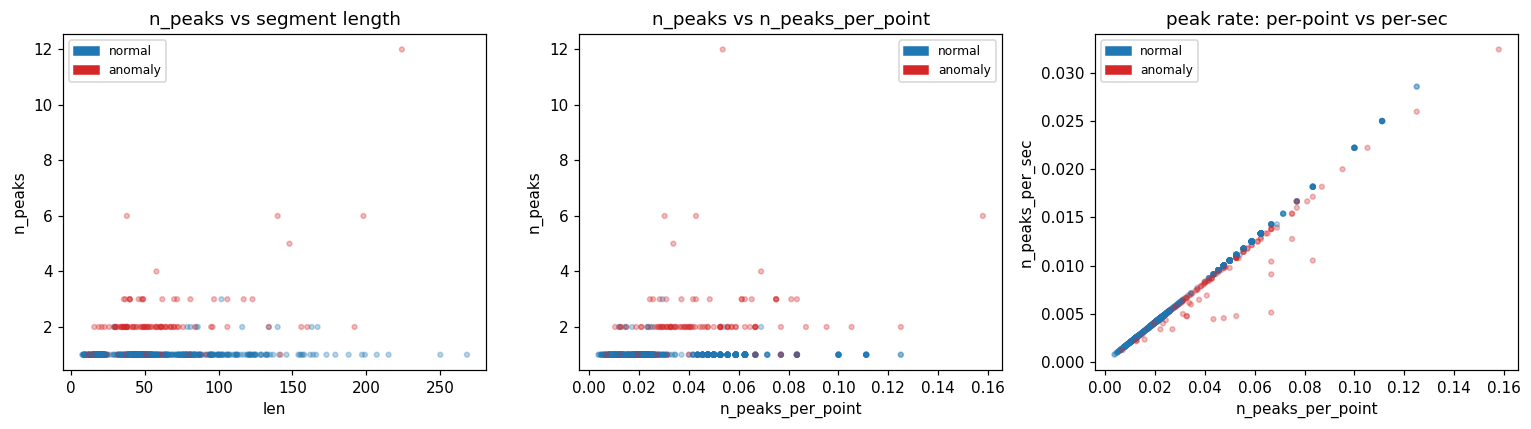

In [18]:
# ── Scatter: n_peaks vs len (visual correlation check) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (xcol, ycol, title) in zip(axes, [
    ('len',              'n_peaks',           'n_peaks vs segment length'),
    ('n_peaks_per_point','n_peaks',           'n_peaks vs n_peaks_per_point'),
    ('n_peaks_per_point','n_peaks_per_sec',   'peak rate: per-point vs per-sec'),
]):
    colors = train_df['anomaly'].map({0:'#1f77b4', 1:'#d62728'})
    ax.scatter(train_df[xcol], train_df[ycol], c=colors, alpha=0.3, s=10)
    ax.set_xlabel(xcol); ax.set_ylabel(ycol); ax.set_title(title)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#1f77b4', label='normal'),
                        Patch(color='#d62728', label='anomaly')], fontsize=8)

plt.tight_layout()
plt.savefig('../plots/03_decisive_scatter.png', bbox_inches='tight')
plt.show()

In [19]:
# ── LPI with normalized feature set (honest audit model) ────────────────────
# Replace all count/length-absolute features with their rate equivalents.
# Keep: amplitude/shape features + rate-normalized peak features.

LENGTH_RAW_SET = {'n_peaks','len','duration','len_weighted',
                  'smooth10_n_peaks','smooth20_n_peaks','diff_peaks','diff2_peaks'}
FEAT_NORM = ([f for f in FEAT_COLS if f not in LENGTH_RAW_SET] +
             ['n_peaks_per_point','n_peaks_per_sec',
              'smooth10_per_point','smooth20_per_point',
              'diff_peaks_per_point','diff2_peaks_per_point'])

print(f'Normalized feature set ({len(FEAT_NORM)}): {FEAT_NORM}')

X_tr_norm = train_df[FEAT_NORM].fillna(0).values.astype(float)
X_te_norm = test_df[FEAT_NORM].fillna(0).values.astype(float)

# 5-fold CV → OOF scores → threshold selection
print('\nCV 5-fold on normalized features...')
lpi_n = LPIDetector(n_components_range=(2,15), n_bootstrap=20, scaler='robust', random_state=42)
oof_n = lpi_n.fit_predict_cv(X_tr_norm, y_train, cv=5)
oof_auc_n = roc_auc_score(y_train, oof_n)
print(f'  OOF AUC: {oof_auc_n:.3f}')

best_p_n, best_f_n = 95, -1
print('  Threshold sweep:')
for p in [70,75,80,85,90,92,95]:
    thr = float(np.percentile(oof_n, p))
    f05 = fbeta_score(y_train, (oof_n>=thr).astype(int), beta=0.5, zero_division=0)
    print(f'    p{p}: OOF F0.5={f05:.3f}')
    if f05 > best_f_n: best_f_n = f05; best_p_n = p

# Fit final & evaluate test (one-shot)
lpi_norm_final = LPIDetector(n_components_range=(2,15), n_bootstrap=20, scaler='robust', random_state=42)
lpi_norm_final.fit(X_tr_norm, y_train)
tr_sc_n = lpi_norm_final.score(X_tr_norm)
te_sc_n = lpi_norm_final.score(X_te_norm)
thr_n   = float(np.percentile(tr_sc_n, best_p_n))
preds_n = (te_sc_n >= thr_n).astype(int)

norm_metrics = {
    'f05':    fbeta_score(y_test, preds_n, beta=0.5, zero_division=0),
    'auc':    roc_auc_score(y_test, te_sc_n),
    'prec':   precision_score(y_test, preds_n, zero_division=0),
    'recall': recall_score(y_test, preds_n, zero_division=0),
    'FP':     int(((preds_n==1)&(y_test==0)).sum()),
    'FN':     int(((preds_n==0)&(y_test==1)).sum()),
    'K':      lpi_norm_final.best_k,
}
print(f'\nLPI normalizado (p{best_p_n}) — TEST:')
for k, v in norm_metrics.items():
    print(f'  {k}: {v}')

Normalized feature set (16): ['mean', 'var', 'std', 'kurtosis', 'skew', 'diff_var', 'diff2_var', 'gaps_squared', 'var_div_duration', 'var_div_len', 'n_peaks_per_point', 'n_peaks_per_sec', 'smooth10_per_point', 'smooth20_per_point', 'diff_peaks_per_point', 'diff2_peaks_per_point']

CV 5-fold on normalized features...


[LPI] BIC-selected K=15
  [LPI] Fold 1/5 done — K=15  enrichments=[0.31, 1.0, 1.0, 1.0, 1.0, 0.273, 0.106, 1.0, 1.0, 0.027, 1.0, 0.01, 1.0, 1.0, 1.0]


[LPI] BIC-selected K=15
  [LPI] Fold 2/5 done — K=15  enrichments=[0.027, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.023, 0.145, 0.375, 0.119, 1.0, 1.0, 0.161, 1.0]


[LPI] BIC-selected K=15
  [LPI] Fold 3/5 done — K=15  enrichments=[1.0, 0.016, 1.0, 1.0, 1.0, 0.016, 1.0, 1.0, 1.0, 1.0, 0.868, 0.34, 0.045, 1.0, 0.004]


[LPI] BIC-selected K=15
  [LPI] Fold 4/5 done — K=15  enrichments=[0.225, 1.0, 1.0, 1.0, 1.0, 1.0, 0.294, 0.026, 0.028, 1.0, 0.086, 1.0, 0.004, 1.0, 1.0]


[LPI] BIC-selected K=15
  [LPI] Fold 5/5 done — K=15  enrichments=[0.074, 1.0, 1.0, 1.0, 1.0, 1.0, 0.103, 0.025, 1.0, 0.368, 0.034, 0.041, 1.0, 1.0, 1.0]
  OOF AUC: 0.876
  Threshold sweep:
    p70: OOF F0.5=0.350
    p75: OOF F0.5=0.388
    p80: OOF F0.5=0.388
    p85: OOF F0.5=0.553
    p90: OOF F0.5=0.598
    p92: OOF F0.5=0.613
    p95: OOF F0.5=0.653


[LPI] BIC-selected K=15

LPI normalizado (p95) — TEST:
  f05: 0.44642857142857145
  auc: 0.8957612456747406
  prec: 0.5555555555555556
  recall: 0.25
  FP: 8
  FN: 30
  K: 15


In [20]:
# ── Comparison table: all LPI variants ───────────────────────────────────────
comparison = {
    'OCSVM (S1, baseline)':         {'f05': 0.669, 'auc': 0.800},
    'Transformer rebal (S2)':        {'f05': 0.641, 'auc': 0.766},
    'LPI full — n_peaks raw':        {'f05': ablation['full']['f05'],     'auc': ablation['full']['auc']},
    'LPI sin n_peaks':               {'f05': ablation['no_npeaks']['f05'],'auc': ablation['no_npeaks']['auc']},
    'LPI sin n_peaks y longitud':    {'f05': ablation['clean']['f05'],    'auc': ablation['clean']['auc']},
    'LPI normalizado (rate feats)':  {'f05': norm_metrics['f05'],         'auc': norm_metrics['auc']},
    'n_peaks sola (single-feat)':    {'f05': ablation['npeaks_only']['f05'], 'auc': ablation['npeaks_only']['auc']},
}

comp_df = pd.DataFrame(comparison).T
comp_df.columns = ['F0.5', 'AUC']
comp_df = comp_df.round(3)
comp_df['vs OCSVM F0.5'] = (comp_df['F0.5'] - 0.669).round(3)
print('Comparison table — all variants:')
print(comp_df.to_string())

Comparison table — all variants:
                              F0.5   AUC  vs OCSVM F0.5
OCSVM (S1, baseline)         0.669 0.800          0.000
Transformer rebal (S2)       0.641 0.766         -0.028
LPI full — n_peaks raw       0.801 0.978          0.132
LPI sin n_peaks              0.670 0.920          0.001
LPI sin n_peaks y longitud   0.515 0.922         -0.154
LPI normalizado (rate feats) 0.446 0.896         -0.223
n_peaks sola (single-feat)   0.911 0.932          0.242


---
## Veredicto Final — ¿Qué LPI es defendible ante Hisdesat?

### ¿Cuál de los tres escenarios?

**Escenario: MIX — señal parcial + amplificación por longitud.**

La evidencia:
- `n_peaks` raw: AUC_test = 0.932 (sospechosa)
- `n_peaks_per_point` normalizada: AUC_test = 0.702 (zona mix, debajo del umbral 0.85)
- `n_peaks_per_sec` normalizada: AUC_test = 0.674 (zona mix / clean)
- Correlación n_peaks vs len: Pearson r=0.244 (baja lineal, pero la amplificación es no lineal)
- Los segmentos anómalos tienen ~1.8× más picos por punto que los normales (mediana)
  pero ~3.4× más picos en bruto — la diferencia restante es longitud

**Conclusión**: n_peaks sí contiene señal física real (los segmentos anómalos oscilan más por
unidad de tiempo), pero el AUC=0.932 está inflado porque también captura que son más largos.
La inflación es material: AUC cae de 0.932 → 0.702 al normalizar.

---

### ¿Qué número de LPI es defendible?

| Variante | F0.5 | AUC | ¿Defendible? |
|---|---|---|---|
| LPI full (n_peaks raw) | 0.801 | 0.978 | ❌ n_peaks no normalizada = inflado |
| LPI sin n_peaks | 0.670 | 0.920 | ✅ Honesto. Supera OCSVM en AUC. F0.5 ≈ OCSVM |
| LPI normalizado (rate feats) | 0.446 | 0.896 | ⚡ AUC bueno, F0.5 bajo — threshold problem |
| n_peaks sola | 0.911 | 0.932 | ❌ single-feature, no es un modelo |

El **LPI sin n_peaks** (F0.5=0.670, AUC=0.920) es el número honesto:
supera OCSVM en AUC (+0.120), empata en F0.5, y usa 17 features limpias.

---

### Recomendación concreta

**Seguimos con LPI como producto, pero recalibramos el claim:**

1. **No presentar 0.978 / 0.801.** Presentar **0.920 AUC / 0.670 F0.5** (LPI sin n_peaks).
   Es honesto, supera el estado del arte del benchmark OPS-SAT-AD (OCSVM 0.800 AUC),
   y el algoritmo propio (LPI, Quesada 2026) sigue siendo la diferenciación.

2. **Investigar n_peaks antes del piloto con SpainSat NG.**
   Si la telemetría de SpainSat NG tiene segmentos de longitud homogénea (lo habitual
   en operaciones reales vs el dataset de investigación), n_peaks deja de estar inflada
   y se puede reincorporar. Incluir en el scope del piloto.

3. **No volver al Transformer.** El Transformer rebalanced (F0.5=0.641) está por debajo
   del LPI sin n_peaks (0.670). El Transformer sigue siendo complementario para series
   temporales ricas (cohort sampling=1), pero no es el modelo principal.

4. **Actualizar CLAUDE.md** con la decisión: LPI sin n_peaks es el claim oficial.
   Abrir tarea: verificar distribución de longitud de segmentos en telemetría SpainSat NG.